In [1]:
import os
import pandas as pd
import numpy as np
from datetime import datetime 
import duckdb
import unicodedata
import sys
from pathlib import Path
from kedro.framework.startup import bootstrap_project
from kedro.framework.session import KedroSession

# 1. Move to project root if we are in the notebooks folder
if Path.cwd().name == "notebooks":
    os.chdir("..")

# 2. Initialize Kedro
project_path = Path.cwd()
bootstrap_project(project_path)

# 3. Create session and get catalog
session = KedroSession.create(project_path)
context = session.load_context()
catalog = context.catalog

print(f"✅ Kedro context loaded! Project root: {project_path}")

[04/20/26 22:06:07] INFO     Using                                                                  ]8;id=474516;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=683876;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\framewo                
                             rk\project\rich_logging.yml' as logging configuration.                                

[04/20/26 22:06:08] WARNING  c:\Users\User\miniconda3\envs\central\Lib\site-packages\requests\__ini ]8;id=423437;file://c:\Users\User\miniconda3\envs\central\Lib\warnings.py\warnings.py]8;;\:]8;id=864355;file://c:\Users\User\miniconda3\envs\central\Lib\warnings.py#110\110]8;;\
                             t__.py:113: RequestsDependencyWarning: urllib3 (2.6.1) or chardet                     
                             (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported                    
                             version!                                                                              
                               warnings.warn(                                                                      
                                                                                                                   

[04/20/26 22:06:09] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=851752;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=800830;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

✅ Kedro context loaded! Project root: g:\Unidades compartidas\Alianzas\3. Data\CENTRAL\central-perm-flow


In [2]:
# Add the 'src' directory to the path
sys.path.append(os.path.abspath("src"))
import central_perm_flow.pipelines.data_processing.nodes as nodes_dproc
import central_perm_flow.pipelines.calac_activos_baj_grad.nodes as nodes_abg

# Fuentes de información

In [3]:
central_calendario_extendido_uptoday = catalog.load('central_calendario_extendido_uptoday')
central_bajas_calendario_academico = catalog.load('central_bajas_calendario_academico')
central_graduados_calendario_academico = catalog.load('central_graduados_calendario_academico')
central_activos_calendario = catalog.load('central_activos_calendario')
central_estados_calac = catalog.load('central_estados_calac')


[04/20/26 22:06:10] INFO     Loading data from central_calendario_extendido_uptoday            ]8;id=212688;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=639272;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from central_bajas_calendario_academico              ]8;id=829072;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=646881;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from central_graduados_calendario_academico          ]8;id=408705;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=709150;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from central_activos_calendario (ParquetDataset)...  ]8;id=199666;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=923779;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

                    INFO     Loading data from central_estados_calac (ParquetDataset)...       ]8;id=692705;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=456800;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

# Parámetros

In [4]:
parameters = catalog.load('parameters')
dict_niveles_duracion = parameters['graduados_calac']['dict_niveles_duracion']

                    INFO     Loading data from parameters (MemoryDataset)...                   ]8;id=515260;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=474131;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [11]:
# parámetros 
columnas_agrupacion = [
    'cohorte_inicial', 'fecha_ingreso', 'nivel_academico', 'nivel', 
    'programa', 'fecha_inicio', 'fecha_fin', 'semana', 
    'semana_acumulada', 'month', 'mes_academico', 'student_journey'
]

columnas_to_order = ['fecha_ingreso','month','fecha_inicio', 'fecha_fin']

group_columnas_agrupacion = [
    'cohorte_inicial', 'fecha_ingreso', 'nivel_academico', 'nivel', 'programa'
]

columnas_tokeep = ['cohorte_inicial',
                    'fecha_ingreso', 
                    'nivel_academico', 
                    'nivel',
                    'programa',  
                    'fecha_inicio', 
                    'fecha_fin', 
                    'semana',
                    'semana_acumulada',
                    'semana_limite',  
                    'month', 
                    'mes_academico', 
                    'nuevos', 
                    'ai',
                    'di',
                    'gi', 
                    'engi',
                    'ci' ]


survival_columns = ['cohorte_inicial',
                    'fecha_ingreso',
                    'nivel_academico',
                    'nivel',
                    'programa',
                    'fecha_inicio',
                    'fecha_fin', 
                    'semana',
                    'semana_acumulada',
                    'semana_limite',
                    'month',
                    'mes_academico',
                    'student_journey',
                    'nuevos',
                    'di',
                    'gi',
                    'engi', 
                    'ci',
                    'di_cum',
                    'gi_cum', 
                    'ai', 
                    'ni']



# Nodes

In [6]:
def podar_tabla_vida(df: pd.DataFrame, dict_duracion: dict) -> pd.DataFrame:
    """
    Filtra las semanas que exceden la duración teórica del programa.
    """
    
    def obtener_limite(row):
        # Normalización robusta
        nivel = str(row['nivel']).lower().strip()
        programa = str(row['programa']).lower().strip()
        
        # Acceso seguro al diccionario
        nivel_dict = dict_duracion.get(nivel, {})
        
        # Prioridad 1: Programa específico
        if programa in nivel_dict:
            return nivel_dict[programa].get('semanas', float('inf'))
        
        # Prioridad 2: Default del nivel
        if 'default' in nivel_dict:
            return nivel_dict['default'].get('semanas', float('inf'))
        
        # Prioridad 3: Estructura plana (especialización)
        return nivel_dict.get('semanas', float('inf'))

    # Aplicamos el cálculo del límite
    df['limite_semanas'] = df.apply(obtener_limite, axis=1)
    
    # Filtrado: mantenemos solo lo que está dentro del rango
    df_podado = df[df['semana_acumulada'] <= df['limite_semanas']].copy()
    
    # Limpieza
    return df_podado.drop(columns=['limite_semanas'])


def generar_cascada_con_punto_cero(central_count_nuevos, central_calendario_extendido_uptoday):
    # 1. Crear el punto de partida (T=0)
    punto_cero = central_count_nuevos.copy()
    
    punto_cero['fecha_inicio'] = punto_cero['fecha_ingreso']
    punto_cero['fecha_fin'] = punto_cero['fecha_ingreso']
    punto_cero['semana'] = 0
    punto_cero['semana_acumulada'] = 0
    punto_cero['month'] = 0
    punto_cero['mes_academico'] = 'm0'
    punto_cero['student_journey'] = 'ingreso'

    # 2. Tu merge original (El recorrido futuro de 1 a N)
    recorrido_futuro = pd.merge(
        central_count_nuevos, 
        central_calendario_extendido_uptoday[[
            'cohorte_inicial', 'fecha_ingreso', 'fecha_inicio', 
            'fecha_fin', 'semana', 'semana_acumulada', 
            'month', 'mes_academico', 'student_journey'
        ]],
        on=['cohorte_inicial', 'fecha_ingreso'],  
        how='left'
    )

    # 3. Concatenar el Punto Cero con el Recorrido
    # Usamos ignore_index=True para mantener el índice limpio
    cascadas_completa = pd.concat([punto_cero, recorrido_futuro], ignore_index=True)

    # 4. Ordenar para que el 'ingreso' (0) quede al principio de cada grupo
    cascadas_completa = cascadas_completa.sort_values(
        by=['cohorte_inicial', 'programa', 'semana_acumulada']
    )

    return cascadas_completa



def aplicar_logica_semana_final(df, dict_niveles):
    def obtener_semana_final(row):
        # Normalizamos los valores para evitar fallos por mayúsculas/minúsculas o espacios
        nivel = str(row['nivel']).lower().strip()
        programa = str(row['programa']).lower().strip()
        
        # 1. Caso Especialización (estructura plana)
        if nivel == 'especializacion':
            return dict_niveles['especializacion']['default']['semanas']
        
        # 2. Casos con excepciones (Maestría y Pregrado)
        if nivel in dict_niveles:
            config = dict_niveles[nivel]
            if programa in config:
                return config[programa]['semanas']
            else:
                return config.get('default', {}).get('semanas', np.nan)
        
        return np.nan

    # Calculamos la semana final para cada registro según el diccionario
    # Se crea una columna temporal 'semana_limite'
    df['semana_limite'] = df.apply(obtener_semana_final, axis=1)

    # Condición: si la 'semana_acumulada' (o 'semana') es igual o mayor a la semana_limite
    # Nota: Uso 'semana_acumulada' porque suele ser el indicador del progreso total.
    mask = df['semana_acumulada'] >= df['semana_limite']
    
    # Asignamos ci = estudiantes_activos donde se cumple la condición
    df.loc[mask, 'engi'] = df.loc[mask, 'ai']
    
    # Opcional: Eliminar la columna auxiliar para dejar el DF limpio
    # df.drop(columns=['semana_limite'], inplace=True)
    
    return df


def calcular_censuras_academica(df: pd.DataFrame, id_cols: list) -> pd.DataFrame:
    """
    Ajusta ni, di y ci para el análisis de supervivencia basado en el 
    recorrido semanal académico.
    """
    # 1. Asegurar orden cronológico estricto
    df = df.sort_values(by=id_cols + ['semana_acumulada'])

    # 2. Identificar el último punto observado en la data para cada estudiante/programa
    # (Esto captura tanto a los que terminaron por 'poda' como a los que llegan a hoy)
    df['es_ultimo_punto'] = (
        df.groupby(id_cols)['semana_acumulada'].transform('max') == df['semana_acumulada']
    )

    # 3. ni (En Riesgo): Ya lo calculamos como el valor al inicio de la semana.
    # Si por alguna razón no viene en el DF, ni es el 'ai' del periodo anterior.
    # (Asumimos que ya tienes 'ni' del paso anterior, si no, descomenta la siguiente línea)
    df['ni'] = df.groupby(id_cols)['ai'].shift(1).fillna(df['nuevos'])

    # 4. di (Eventos - Bajas):
    # Usamos el 'di' que ya calculaste (conteo de identificaciones con baja).
    # IMPORTANTE: En el último punto observado, no registramos bajas nuevas 
    # porque no podemos confirmar si ocurrió el evento o se acabó el tiempo de observación.
    #df['di_final'] = np.where(~df['es_ultimo_punto'], df['di'], 0)

    # 5. ci (Censuras):
    # Son los estudiantes que permanecen activos (ai) en el último punto 
    # observado del dataset. 
    df['ci'] = np.where(df['es_ultimo_punto'], df['ai'] + df['gi'], 0)

    # 6. Limpieza y preparación final
    # Eliminamos columnas auxiliares para no ensuciar el catálogo
    columnas_finales = df.drop(columns=['es_ultimo_punto'])
    
    return columnas_finales


def calcular_km_y_eti_dinamico(
    df: pd.DataFrame, 
    group_cols: list, 
    conf_z: float = 1.96
) -> tuple:
    """
    Calcula Kaplan-Meier y ETI.
    Considera que 'nuevos' ya es constante en todas las semanas de la cohorte.
    """
    
    # 1. Agregación dinámica
    # Para 'nuevos', usamos max() porque el valor es constante por cohorte
    # Para ai, usamos sum() porque representa el stock de esa semana
    # Para di, gi, engi, ci, usamos sum() para consolidar eventos de la semana
    df_agrupado = (
        df.groupby(group_cols + ['semana_acumulada'])
        .agg({
            'ai': 'sum',
            'di': 'sum',
            'gi': 'sum',
            'engi': 'sum',
            'ci': 'sum',
            'nuevos': 'sum' # <--- CAMBIO CRÍTICO: No sumar valores repetidos
        })
        .reset_index()
    )

    # 2. Ordenar cronológicamente
    df_agrupado = df_agrupado.sort_values(by=group_cols + ['semana_acumulada'])

    # 3. n_total dinámico
    # Si agrupamos por 'programa', sumamos los máximos de cada cohorte (si existieran)
    # o simplemente tomamos el máximo si el grupo es la cohorte misma.
    df_agrupado['n_total'] = df_agrupado.groupby(group_cols)['nuevos'].transform('max')

    # 4. Cálculo de ni (En riesgo)
    # n_i = activos_final + censuras_final + bajas_final
    df_agrupado['ni'] = df_agrupado['ai'] + df_agrupado['ci'] + df_agrupado['di']
    df_agrupado['ni'] = df_agrupado['ni'].clip(lower=0)

    # 5. Agrupación para métricas de probabilidad
    grouped = df_agrupado.groupby(group_cols)

    # 6. Kaplan-Meier (Supervivencia)
    df_agrupado['qi'] = np.where(df_agrupado['ni'] > 0, df_agrupado['di'] / df_agrupado['ni'], 0)
    df_agrupado['pi'] = 1 - df_agrupado['qi']
    df_agrupado['km'] = grouped['pi'].cumprod()

    # 7. Greenwood (Varianza e Intervalos)
    mask = (df_agrupado['ni'] > df_agrupado['di']) & (df_agrupado['ni'] > 0)
    df_agrupado['greenwood_term'] = np.where(
        mask, 
        df_agrupado['di'] / (df_agrupado['ni'] * (df_agrupado['ni'] - df_agrupado['di'])), 
        0
    )
    df_agrupado['km_se'] = np.sqrt(df_agrupado['km']**2 * grouped['greenwood_term'].cumsum())
    df_agrupado['km_ic_inf'] = (df_agrupado['km'] - (conf_z * df_agrupado['km_se'])).clip(0, 1)
    df_agrupado['km_ic_sup'] = (df_agrupado['km'] + (conf_z * df_agrupado['km_se'])).clip(0, 1)

    # 8. ETI (Eficiencia Terminal)
    # gi_engi_prev: Acumulado de ci (que incluye graduados/egresados) hasta la semana anterior
    ci_cum = grouped['ci'].cumsum()
    gi_engi_prev = grouped['ci'].transform(lambda x: x.cumsum().shift(0).fillna(0))
    
    df_agrupado['nuevos'] = df_agrupado['n_total']
    denominador_eti = df_agrupado['n_total'] - gi_engi_prev
    df_agrupado['n_total'] = df_agrupado['n_total'] - gi_engi_prev
    df_agrupado['eti'] = np.where(denominador_eti > 0, df_agrupado['ai'] / denominador_eti, 0)
    # Calculamos la ETI cruda
    eti_cruda = np.where(denominador_eti > 0, df_agrupado['ai'] / denominador_eti, 0)

    # Obtenemos la ETI de la semana anterior por grupo
    eti_anterior = grouped['eti'].shift(1).fillna(1.0) 

    # Si la ETI cruda es mayor que 1 (o mayor que la anterior, según tu regla), 
    # se queda con el valor anterior.
    # Nota: Usamos clip(upper=1) para asegurar que nunca exceda el 100%
    df_agrupado['eti'] = np.where(eti_cruda > 1.0, eti_anterior, eti_cruda)

    # Cifras acumuladas
    df_agrupado['ci_cum'] = gi_engi_prev
    df_agrupado['di_cum'] =  grouped['di'].transform(lambda x: x.cumsum().shift(0).fillna(0))
    df_agrupado['gi_cum'] =  grouped['gi'].transform(lambda x: x.cumsum().shift(0).fillna(0))

    # Selección final de columnas
    cols_finales = group_cols + [
        'semana_acumulada','nuevos', 'n_total', 'ni', 'di','di_cum', 'gi', 'gi_cum', 'engi', 'ci','ci_cum', 'ai', 
        'qi', 'pi', 'km', 'km_se', 'km_ic_inf', 'km_ic_sup', 'eti'
    ]
    
    return df_agrupado[cols_finales].reset_index(drop=True)

# Lifetables
- Cascadas 
- Sobrevivencia

## Semanal

In [12]:
#--------------------------------------------------------------------
# Inicio
#--------------------------------------------------------------------

central_count_nuevos = (central_estados_calac.loc[:, ['cohorte_inicial',
                                                      'fecha_ingreso',
                                                      'nivel_academico', 
                                                      'nivel',
                                                      'programa',
                                                      'identificacion']]
                            .groupby(['cohorte_inicial',
                                      'fecha_ingreso',
                                      'nivel_academico', 
                                      'nivel',
                                      'programa'])
                            .agg(nuevos= ('identificacion','count'))
                            .reset_index()
                            .sort_values(by=['fecha_ingreso','nuevos'], ascending=[True,False])
                            )
cascadas_inicial_calendario  = generar_cascada_con_punto_cero(central_count_nuevos, central_calendario_extendido_uptoday)

#--------------------------------------------------------------------
# Bajas
#--------------------------------------------------------------------
central_count_bajas = (central_bajas_calendario_academico.loc[:, columnas_agrupacion + ['di']]
                       .groupby(columnas_agrupacion)
                       .agg({'di': 'sum'})
                       .reset_index()
                       .sort_values(by=columnas_to_order, ascending=True))

# Realizar el merge
cascadas_semanal = pd.merge(
    cascadas_inicial_calendario,
    central_count_bajas[columnas_agrupacion + ['di']], # Solo traemos las llaves y la métrica
    on=columnas_agrupacion,
    how='left'
)

#--------------------------------------------------------------------
# Graduados
#--------------------------------------------------------------------
cascadas_semanal['di'] = cascadas_semanal['di'].fillna(0)

central_count_graduados = (central_graduados_calendario_academico.loc[:, columnas_agrupacion + ['gi']]
                            .groupby(columnas_agrupacion)
                            .agg({'gi': 'sum'})
                            .reset_index()
                            .sort_values(by=['fecha_ingreso','month','fecha_inicio', 'fecha_fin'], ascending=True))

# Realizar el merge
cascadas_semanal = pd.merge(
    cascadas_semanal,
    central_count_graduados[columnas_agrupacion + ['gi']], 
    on=columnas_agrupacion,
    how='left'
)
cascadas_semanal['gi'] = cascadas_semanal['gi'].fillna(0)


#--------------------------------------------------------------------
# Poda del calendario
#--------------------------------------------------------------------
cascadas_semanal_podada = podar_tabla_vida(cascadas_semanal,dict_niveles_duracion)

#--------------------------------------------------------------------
# Estadísticas de sobrevivencia
#--------------------------------------------------------------------

# Calcular la baja acumulada (di_cum, gi_cum) por cohorte,
# nivel, nivel_academico, programa ordenado por fecha_inicio, fecha_fin, semana_acumulada y month
cascadas_semanal_podada['di_cum'] = cascadas_semanal_podada.groupby(['fecha_ingreso',
                                                        'nivel_academico',
                                                        'nivel',
                                                        'programa'
                                    ])['di'].cumsum()

cascadas_semanal_podada['gi_cum'] = cascadas_semanal_podada.groupby(['fecha_ingreso',
                                                        'nivel_academico',
                                                        'nivel',
                                                        'programa'])['gi'].cumsum()

# Calcular la cantidad de estudiantes activos restando los ingresos menos la baja acumulada
cascadas_semanal_podada['ai'] = cascadas_semanal_podada['nuevos'] - cascadas_semanal_podada['di_cum'] - cascadas_semanal_podada['gi_cum']

# Asegurar el orden cronológico antes de hacer el shift
cascadas_semanal_podada = cascadas_semanal_podada.sort_values(
    by=group_columnas_agrupacion + ['semana_acumulada']
)

# Aplicar lógica semana final 
cascadas_semanal_podada = aplicar_logica_semana_final(cascadas_semanal_podada, dict_niveles_duracion)
mask_engi = cascadas_semanal_podada['engi'] >= cascadas_semanal_podada['gi']
cascadas_semanal_podada.loc[mask_engi,'engi'] = cascadas_semanal_podada['engi'] - cascadas_semanal_podada['gi'] 
cascadas_semanal_podada['engi'] = cascadas_semanal_podada['engi'].fillna(0)

# Aplicar las censuras
cascadas_semanal_podada_censuras =  calcular_censuras_academica(cascadas_semanal_podada,group_columnas_agrupacion)
# Columnas para manetener 
cascadas_semanal_podada_censuras = cascadas_semanal_podada_censuras.loc[:,columnas_tokeep]

In [ ]:
group_cols = ['cohorte_inicial', 'fecha_ingreso', 'nivel_academico', 'nivel',
                    'programa', ]

# tabla de vida
central_tabla_vida = calcular_km_y_eti_dinamico(
    df = cascadas_semanal_podada_censuras , 
    group_cols = group_cols
)


### Estudiantes Nuevos

In [7]:
# Punto de inicio semana y mes igual a 0 
central_count_nuevos = (central_estados_calac.loc[:, ['cohorte_inicial',
                                                      'fecha_ingreso',
                                                      'nivel_academico', 
                                                      'nivel',
                                                      'programa',
                                                      'identificacion']]
                            .groupby(['cohorte_inicial',
                                      'fecha_ingreso',
                                      'nivel_academico', 
                                      'nivel',
                                      'programa'])
                            .agg(nuevos= ('identificacion','count'))
                            .reset_index()
                            .sort_values(by=['fecha_ingreso','nuevos'], ascending=[True,False])
                            )
cascadas_inicial_calendario  = generar_cascada_con_punto_cero(central_count_nuevos, central_calendario_extendido_uptoday)

### Bajas

In [8]:
# Conteo Bajas por semana 
central_count_bajas = (central_bajas_calendario_academico.loc[:, columnas_agrupacion + ['di']]
                       .groupby(columnas_agrupacion)
                       .agg({'di': 'sum'})
                       .reset_index()
                       .sort_values(by=columnas_to_order, ascending=True))


In [ ]:
# Realizar el merge
cascadas_semanal = pd.merge(
    cascadas_inicial_calendario,
    central_count_bajas[columnas_agrupacion + ['di']], # Solo traemos las llaves y la métrica
    on=columnas_agrupacion,
    how='left'
)

# Llenar vacíos: si no hubo baja esa semana, es 0
cascadas_semanal['di'] = cascadas_semanal['di'].fillna(0)

### Graduados

In [10]:
central_count_graduados = (central_graduados_calendario_academico.loc[:, columnas_agrupacion + ['gi']]
                            .groupby(columnas_agrupacion)
                            .agg({'gi': 'sum'})
                            .reset_index()
                            .sort_values(by=['fecha_ingreso','month','fecha_inicio', 'fecha_fin'], ascending=True))


In [11]:
# Supongamos que tienes un central_count_graduados con la columna 'gi'
cascadas_semanal = pd.merge(
    cascadas_semanal,
    central_count_graduados[columnas_agrupacion + ['gi']], 
    on=columnas_agrupacion,
    how='left'
)
cascadas_semanal['gi'] = cascadas_semanal['gi'].fillna(0)

# Construcción de las tablas de vida 

## Podas

In [12]:
cascadas_semanal_podada = podar_tabla_vida(cascadas_semanal,dict_niveles_duracion)

# Calcular las deserciones acumuladas, las graduaciones acumuladas y los ai: estudiantes activos

In [13]:

# 5. Calcular la baja acumulada (di_cum) por cohorte, nivel y programa ordenado por fecha_inicio, fecha_fin, semana_acumulada y month
cascadas_semanal_podada['di_cum'] = cascadas_semanal_podada.groupby(['fecha_ingreso',
                                                        'nivel_academico',
                                                        'nivel',
                                                        'programa'
                                    ])['di'].cumsum()

cascadas_semanal_podada['gi_cum'] = cascadas_semanal_podada.groupby(['fecha_ingreso',
                                                        'nivel_academico',
                                                        'nivel',
                                                        'programa'])['gi'].cumsum()

# 6. Calcular la cantidad de estudiantes activos restando los ingresos menos la baja acumulada
cascadas_semanal_podada['ai'] = cascadas_semanal_podada['nuevos'] - cascadas_semanal_podada['di_cum'] - cascadas_semanal_podada['gi_cum']

In [14]:
# 1. Definir las columnas de agrupación (tus llaves de negocio)
group_columnas_agrupacion = [
    'cohorte_inicial', 'fecha_ingreso', 'nivel_academico', 'nivel', 'programa'
]

# 2. Asegurar el orden cronológico antes de hacer el shift
cascadas_semanal_podada = cascadas_semanal_podada.sort_values(
    by=group_columnas_agrupacion + ['semana_acumulada']
)

In [15]:
cascadas_semanal_podada = aplicar_logica_semana_final(cascadas_semanal_podada, dict_niveles_duracion)
mask_engi = cascadas_semanal_podada['engi'] >= cascadas_semanal_podada['gi']
cascadas_semanal_podada.loc[mask_engi,'engi'] = cascadas_semanal_podada['engi'] - cascadas_semanal_podada['gi'] 
cascadas_semanal_podada['engi'] = cascadas_semanal_podada['engi'].fillna(0)

In [16]:
cascadas_semanal_podada_censuras =  calcular_censuras_academica(cascadas_semanal_podada,group_columnas_agrupacion)

In [17]:
columnas = ['cohorte_inicial', 'fecha_ingreso', 'nivel_academico', 'nivel',
       'programa',  'fecha_inicio', 'fecha_fin', 'semana',
       'semana_acumulada','semana_limite',  'month', 'mes_academico', 'nuevos', 'ai','di',
       'gi', 'engi','ci' ]
group_cols = ['cohorte_inicial', 'fecha_ingreso', 'nivel_academico', 'nivel',
                    'programa', ]



# Programa

In [22]:
central_tabla_vida = calcular_km_y_eti_dinamico(
    df = cascadas_semanal_podada_censuras.loc[:,columnas] , 
    group_cols = group_cols
)

In [23]:
mask_cohorte = central_tabla_vida['cohorte_inicial'] == '2026 1a'
mask_nivel = central_tabla_vida['nivel_academico'] == 'pregrado'
mask_programa = central_tabla_vida['programa'] == 'derecho'
central_tabla_vida[mask_cohorte & mask_nivel & mask_programa]

,cohorte_inicial,fecha_ingreso,nivel_academico,nivel,programa,semana_acumulada,nuevos,n_total,ni,di,...,ci,ci_cum,ai,qi,pi,km,km_se,km_ic_inf,km_ic_sup,eti
872,2026 1a,2026-01-19,pregrado,pregrado,derecho,0,94,94.0,94.0,0.0,...,0.0,0.0,94.0,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
873,2026 1a,2026-01-19,pregrado,pregrado,derecho,1,94,94.0,94.0,0.0,...,0.0,0.0,94.0,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
874,2026 1a,2026-01-19,pregrado,pregrado,derecho,2,94,94.0,94.0,0.0,...,0.0,0.0,94.0,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
875,2026 1a,2026-01-19,pregrado,pregrado,derecho,3,94,94.0,94.0,5.0,...,0.0,0.0,89.0,0.053191,0.946809,0.946809,0.023147,0.901441,0.992176,0.946809
876,2026 1a,2026-01-19,pregrado,pregrado,derecho,4,94,94.0,89.0,1.0,...,0.0,0.0,88.0,0.011236,0.988764,0.936170,0.025213,0.886753,0.985588,0.936170
877,2026 1a,2026-01-19,pregrado,pregrado,derecho,5,94,94.0,88.0,1.0,...,0.0,0.0,87.0,0.011364,0.988636,0.925532,0.027078,0.872459,0.978605,0.925532
878,2026 1a,2026-01-19,pregrado,pregrado,derecho,6,94,94.0,87.0,1.0,...,0.0,0.0,86.0,0.011494,0.988506,0.914894,0.028781,0.858483,0.971304,0.914894
879,2026 1a,2026-01-19,pregrado,pregrado,derecho,7,94,94.0,86.0,0.0,...,0.0,0.0,86.0,0.000000,1.000000,0.914894,0.028781,0.858483,0.971304,0.914894
880,2026 1a,2026-01-19,pregrado,pregrado,derecho,8,94,94.0,86.0,0.0,...,0.0,0.0,86.0,0.000000,1.000000,0.914894,0.028781,0.858483,0.971304,0.914894
881,2026 1a,2026-01-19,pregrado,pregrado,derecho,9,94,94.0,86.0,0.0,...,0.0,0.0,86.0,0.000000,1.000000,0.914894,0.028781,0.858483,0.971304,0.914894


# Nivel Académico

In [32]:
central_tabla_vida = calcular_km_y_eti_dinamico(
    df = cascadas_semanal_podada_censuras.loc[:,columnas] , 
    group_cols =  ['cohorte_inicial', 'fecha_ingreso',  'nivel_academico']
) 

In [33]:
mask_cohorte = central_tabla_vida['cohorte_inicial'] == '2025 1a'
mask_nivel = central_tabla_vida['nivel_academico'] == 'posgrado'
#mask_programa = central_tabla_vida['programa'] == 'auditoria y control'
central_tabla_vida.loc[mask_cohorte ,['cohorte_inicial','nivel_academico','semana_acumulada','nuevos', 'n_total', 'ni', 'di', 'di_cum', 'gi', 'gi_cum',
       'engi', 'ci', 'ci_cum', 'ai', 'qi', 'pi', 'km', 'km_se', 'km_ic_inf',
       'km_ic_sup', 'eti']] 

,cohorte_inicial,nivel_academico,semana_acumulada,nuevos,n_total,ni,di,di_cum,gi,gi_cum,...,ci,ci_cum,ai,qi,pi,km,km_se,km_ic_inf,km_ic_sup,eti
0,2025 1a,posgrado,0,110,110.0,110.0,0.0,0.0,0.0,0.0,...,0.0,0.0,110.0,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
1,2025 1a,posgrado,1,110,110.0,110.0,0.0,0.0,0.0,0.0,...,0.0,0.0,110.0,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
2,2025 1a,posgrado,2,110,110.0,110.0,0.0,0.0,0.0,0.0,...,0.0,0.0,110.0,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
3,2025 1a,posgrado,3,110,110.0,110.0,5.0,5.0,0.0,0.0,...,0.0,0.0,105.0,0.045455,0.954545,0.954545,0.019861,0.915619,0.993472,0.954545
4,2025 1a,posgrado,4,110,110.0,105.0,0.0,5.0,0.0,0.0,...,0.0,0.0,105.0,0.000000,1.000000,0.954545,0.019861,0.915619,0.993472,0.954545
5,2025 1a,posgrado,5,110,110.0,105.0,1.0,6.0,0.0,0.0,...,0.0,0.0,104.0,0.009524,0.990476,0.945455,0.021652,0.903016,0.987893,0.945455
6,2025 1a,posgrado,6,110,110.0,104.0,0.0,6.0,0.0,0.0,...,0.0,0.0,104.0,0.000000,1.000000,0.945455,0.021652,0.903016,0.987893,0.945455
7,2025 1a,posgrado,7,110,110.0,104.0,0.0,6.0,0.0,0.0,...,0.0,0.0,104.0,0.000000,1.000000,0.945455,0.021652,0.903016,0.987893,0.945455
8,2025 1a,posgrado,8,110,110.0,104.0,0.0,6.0,0.0,0.0,...,0.0,0.0,104.0,0.000000,1.000000,0.945455,0.021652,0.903016,0.987893,0.945455
9,2025 1a,posgrado,9,110,110.0,104.0,1.0,7.0,0.0,0.0,...,0.0,0.0,103.0,0.009615,0.990385,0.936364,0.023274,0.890746,0.981981,0.936364


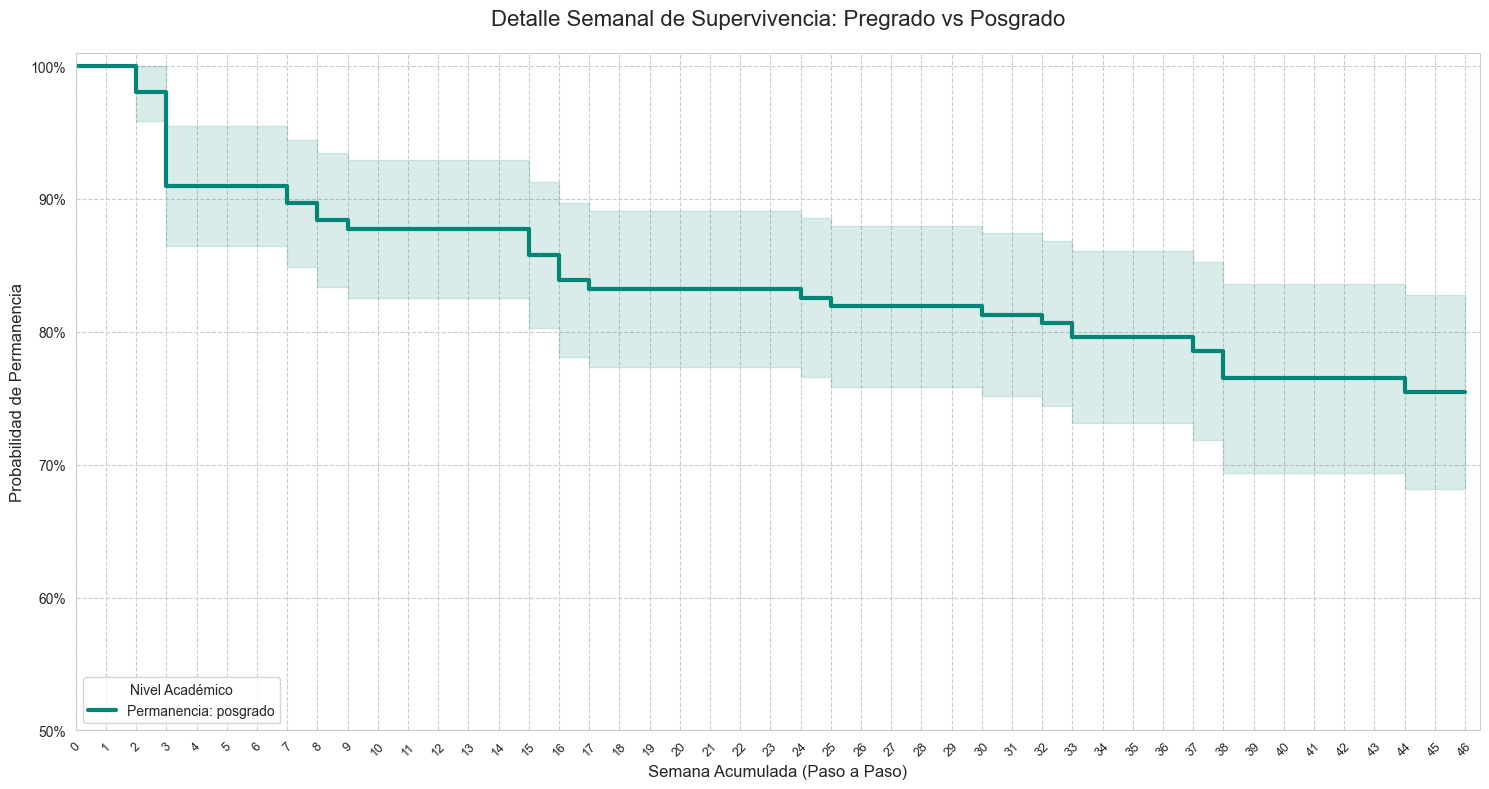

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

def graficar_km_zoom_unitario(df_total):
    # 1. Filtrar niveles (normalizando a minúsculas para el filtro)
    df_plot = df_total[df_total['nivel_academico'].str.lower().isin(['pregrado', 'posgrado'])].copy()
    
    # 2. Configuración estética
    plt.figure(figsize=(15, 8)) # Aumentamos ancho para dar espacio a los ticks unitarios
    sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})
    
    colores = {
        'PREGRADO': '#6A0DAD', # Morado
        'POSGRADO': '#008577'  # Verde Esmeralda
    } 
    
    for nivel in df_plot['nivel_academico'].unique():
        data_nivel = df_plot[df_plot['nivel_academico'] == nivel].sort_values('semana_acumulada')
        color_actual = colores.get(nivel.upper(), 'gray')
        
        plt.step(data_nivel['semana_acumulada'], 
                 data_nivel['km'], 
                 where='post', 
                 label=f'Permanencia: {nivel}', 
                 color=color_actual, 
                 lw=3)
        
        plt.fill_between(data_nivel['semana_acumulada'], 
                         data_nivel['km_ic_inf'], 
                         data_nivel['km_ic_sup'], 
                         step='post', 
                         alpha=0.15, 
                         color=color_actual)

    # 3. CONFIGURACIÓN DE EJES (Zoom y Unidad por Unidad)
    ax = plt.gca()
    
    # Eje Y: Zoom al 80% - 100%
    plt.ylim(0.5, 1.01)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
    
    # Eje X: Unidad por unidad
    # Determinamos el rango máximo de semanas presentes en el data
    max_semanas = int(df_plot['semana_acumulada'].max())
    ax.set_xticks(range(0, max_semanas + 1, 1)) # Marcas cada 1 unidad
    
    # Rotamos las etiquetas si hay muchas semanas para evitar solapamiento
    plt.xticks(rotation=45, fontsize=9)
    plt.xlim(0, max_semanas + 0.5)

    # 4. Etiquetas y Leyenda
    plt.title('Detalle Semanal de Supervivencia: Pregrado vs Posgrado', fontsize=16, pad=20)
    plt.xlabel('Semana Acumulada (Paso a Paso)', fontsize=12)
    plt.ylabel('Probabilidad de Permanencia', fontsize=12)
    
    plt.legend(title="Nivel Académico", frameon=True, loc='lower left')
    plt.tight_layout()
    plt.show()

# Ejecución
mask_cohorte = central_tabla_vida['cohorte_inicial'] == '2025 1b'
df_final_plot = central_tabla_vida.loc[mask_cohorte]

graficar_km_zoom_unitario(df_final_plot)

In [ ]:
import pandas as pd
import numpy as np

def calcular_hazard_ratio_niveles(df_km: pd.DataFrame, grupo_ref='posgrado', grupo_comp='pregrado'):
    """
    Estima el Hazard Ratio entre dos niveles académicos usando la data agregada.
    """
    # 1. Preparar data: Asegurar que las columnas necesarias existan
    df = df_km.copy()
    df['nivel_academico'] = df['nivel_academico'].str.lower()
    
    # 2. Filtrar los dos grupos
    g1 = df[df['nivel_academico'] == grupo_comp].sort_values('semana_acumulada')
    g2 = df[df['nivel_academico'] == grupo_ref].sort_values('semana_acumulada')
    
    # Unimos por semana para calcular el riesgo total en cada punto del tiempo
    merged = pd.merge(
        g1[['semana_acumulada', 'ni', 'di']], 
        g2[['semana_acumulada', 'ni', 'di']], 
        on='semana_acumulada', suffixes=('_comp', '_ref')
    )
    
    # 3. Cálculo de Eventos Esperados (Mantel-Haenszel logic)
    # Riesgo total en la semana i
    merged['n_total_i'] = merged['ni_comp'] + merged['ni_ref']
    merged['d_total_i'] = merged['di_comp'] + merged['di_ref']
    
    # Eventos esperados en el grupo de comparación si el riesgo fuera igual
    merged['e_comp'] = (merged['ni_comp'] * merged['d_total_i']) / merged['n_total_i']
    
    # 4. Totales
    O_comp = merged['di_comp'].sum() # Observados comparación
    E_comp = merged['e_comp'].sum()  # Esperados comparación
    
    # El Hazard Ratio simplificado (O/E)
    # Representa cuánto más (o menos) riesgo tiene el grupo_comp vs grupo_ref
    hr = (O_comp / E_comp) / ((merged['di_ref'].sum()) / (merged['di_ref'].sum() + O_comp - E_comp))
    
    # Alternativa rápida: Ratio de Log-Rank
    hr_logrank = (O_comp / E_comp)
    
    return {
        'hazard_ratio': hr_logrank,
        'interpretacion': f"El grupo {grupo_comp} tiene un riesgo de deserción {hr_logrank:.2f} veces mayor que {grupo_ref}"
    }

# Ejemplo de uso:
resultados_hr = calcular_hazard_ratio_niveles(central_tabla_vida)
# print(resultados_hr['interpretacion'])

# Cohortes

In [27]:
central_tabla_vida = calcular_km_y_eti_dinamico(
    df = cascadas_semanal_podada_censuras.loc[:,columnas] , 
    group_cols =  ['cohorte_inicial', 'fecha_ingreso']
) 

In [29]:
central_tabla_vida['cohorte_inicial'].unique()


<StringArray>
['2025 1a', '2025 1b', '2025 1c', '2025 1d', '2025 1e', '2026 1a', '2026 1b']
Length: 7, dtype: str